In [2]:
# ── IMPORTS ──────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from prophet import Prophet

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgb.__version__}")


✅ All libraries imported successfully!
Pandas version: 2.2.3
XGBoost version: 3.2.0


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)
print("✅ Imports done!")

✅ Imports done!


In [4]:
# ── 730 days = 2 full years of daily retail sales ──
n_days = 730
dates = pd.date_range(start="2022-01-01", periods=n_days, freq="D")

# 1. Upward trend (business growing)
trend = np.linspace(1000, 1500, n_days)

# 2. Weekly pattern (weekends sell more)
weekly = 200 * np.sin(2 * np.pi * np.arange(n_days) / 7 + 1.5)

# 3. Annual seasonality (holiday peaks, summer dips)
annual = (
    300 * np.sin(2 * np.pi * np.arange(n_days) / 365 - 1.5)
    + 150 * np.sin(4 * np.pi * np.arange(n_days) / 365)
)

# 4. Holiday spikes
holiday_boost = np.zeros(n_days)
for i, d in enumerate(dates):
    if d.month == 12 and d.day >= 20:        # Christmas week
        holiday_boost[i] = 900
    elif d.month == 11 and 25 <= d.day <= 30: # Black Friday
        holiday_boost[i] = 1300
    elif d.month == 7 and d.day == 4:         # 4th of July
        holiday_boost[i] = 450
    elif d.month == 2 and d.day == 14:        # Valentine's Day
        holiday_boost[i] = 350

# 5. Random promo flash sales
promo = np.zeros(n_days)
promo_days = np.random.choice(n_days, size=30, replace=False)
promo[promo_days] = np.random.uniform(200, 600, size=30)

# 6. Random noise (real world randomness)
noise = np.random.normal(0, 80, n_days)

# ── Combine everything
sales = trend + weekly + annual + holiday_boost + promo + noise
sales = np.clip(sales, 100, None)  # no negative sales

print("✅ Data generated!")
print(f"   Days      : {n_days}")
print(f"   Avg Sales : ${sales.mean():,.2f}")
print(f"   Max Sales : ${sales.max():,.2f}")
print(f"   Min Sales : ${sales.min():,.2f}")

✅ Data generated!
   Days      : 730
   Avg Sales : $1,326.95
   Max Sales : $2,721.67
   Min Sales : $418.52


In [5]:
df = pd.DataFrame({
    "sales"       : sales.round(2),
    "trend"       : trend.round(2),
    "is_weekend"  : [1 if d.weekday() >= 5 else 0 for d in dates],
    "is_holiday"  : [1 if h > 0 else 0 for h in holiday_boost],
    "is_promo"    : [1 if p > 0 else 0 for p in promo],
    "month"       : [d.month for d in dates],
    "day_of_week" : [d.weekday() for d in dates],
    "quarter"     : [d.quarter for d in dates],
}, index=dates)

df.index.name = "date"

# Save to CSV
os.makedirs("data", exist_ok=True)
df.to_csv("data/retail_sales.csv")

print("✅ Saved to data/retail_sales.csv")
print(f"\n{df.head()}")



✅ Saved to data/retail_sales.csv

             sales    trend  is_weekend  is_holiday  is_promo  month  \
date                                                                   
2022-01-01  884.68  1000.00           1           0         0      1   
2022-01-02  956.03  1000.69           1           0         0      1   
2022-01-03  719.61  1001.37           0           0         0      1   
2022-01-04  593.05  1002.06           0           0         0      1   
2022-01-05  418.52  1002.74           0           0         0      1   

            day_of_week  quarter  
date                              
2022-01-01            5        1  
2022-01-02            6        1  
2022-01-03            0        1  
2022-01-04            1        1  
2022-01-05            2        1  


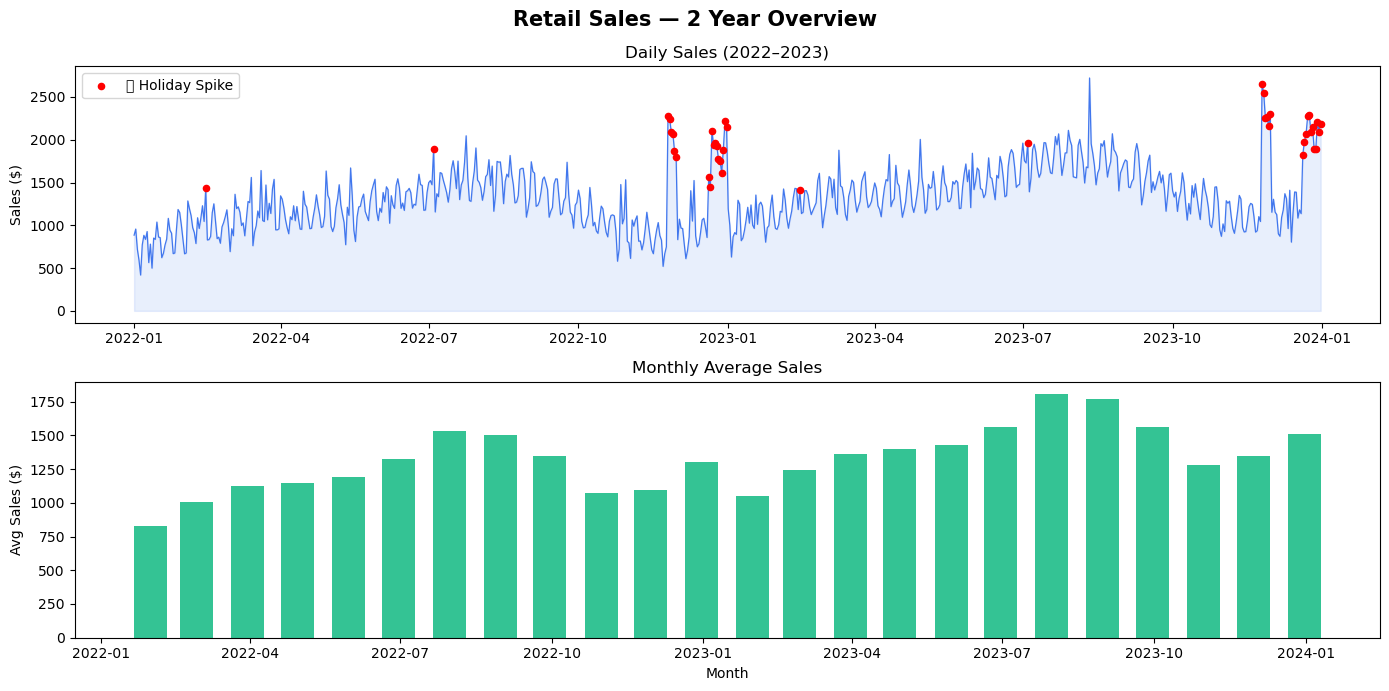

✅ Chart saved to outputs/step2_overview.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Retail Sales — 2 Year Overview", fontsize=15, fontweight="bold")

# ── Top: Full sales line
axes[0].plot(df.index, df["sales"], color="#2563EB", linewidth=0.9, alpha=0.85)
axes[0].fill_between(df.index, df["sales"], alpha=0.1, color="#2563EB")
axes[0].set_title("Daily Sales (2022–2023)")
axes[0].set_ylabel("Sales ($)")

# Mark holidays in red
holiday_df = df[df["is_holiday"] == 1]
axes[0].scatter(holiday_df.index, holiday_df["sales"],
                color="red", s=20, zorder=5, label="🎄 Holiday Spike")
axes[0].legend()

# ── Bottom: Monthly average bar chart
monthly_avg = df["sales"].resample("ME").mean()
axes[1].bar(monthly_avg.index, monthly_avg.values,
            color="#10B981", width=20, alpha=0.85)
axes[1].set_title("Monthly Average Sales")
axes[1].set_ylabel("Avg Sales ($)")
axes[1].set_xlabel("Month")

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/step2_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to outputs/step2_overview.png")

In [7]:
print("=" * 50)
print("  RETAIL SALES — EDA SUMMARY")
print("=" * 50)
print(f"\n📅 Date Range : {df.index.min().date()} → {df.index.max().date()}")
print(f"📦 Total Days : {len(df)}")
print(f"\n💰 Sales Statistics:")
print(f"   Mean   : ${df['sales'].mean():,.2f}")
print(f"   Median : ${df['sales'].median():,.2f}")
print(f"   Std Dev: ${df['sales'].std():,.2f}")
print(f"   Min    : ${df['sales'].min():,.2f}")
print(f"   Max    : ${df['sales'].max():,.2f}")
print(f"\n📊 Special Days:")
print(f"   Weekend days  : {df['is_weekend'].sum()}")
print(f"   Holiday days  : {df['is_holiday'].sum()}")
print(f"   Promo days    : {df['is_promo'].sum()}")
print(f"\n   Avg sales on weekdays : ${df[df['is_weekend']==0]['sales'].mean():,.2f}")
print(f"   Avg sales on weekends : ${df[df['is_weekend']==1]['sales'].mean():,.2f}")
print(f"   Avg sales on holidays : ${df[df['is_holiday']==1]['sales'].mean():,.2f}")
print(f"   Avg sales on promos   : ${df[df['is_promo']==1]['sales'].mean():,.2f}")

  RETAIL SALES — EDA SUMMARY

📅 Date Range : 2022-01-01 → 2023-12-31
📦 Total Days : 730

💰 Sales Statistics:
   Mean   : $1,326.95
   Median : $1,293.59
   Std Dev: $356.90
   Min    : $418.52
   Max    : $2,721.67

📊 Special Days:
   Weekend days  : 210
   Holiday days  : 40
   Promo days    : 30

   Avg sales on weekdays : $1,262.28
   Avg sales on weekends : $1,487.10
   Avg sales on holidays : $2,012.81
   Avg sales on promos   : $1,680.49


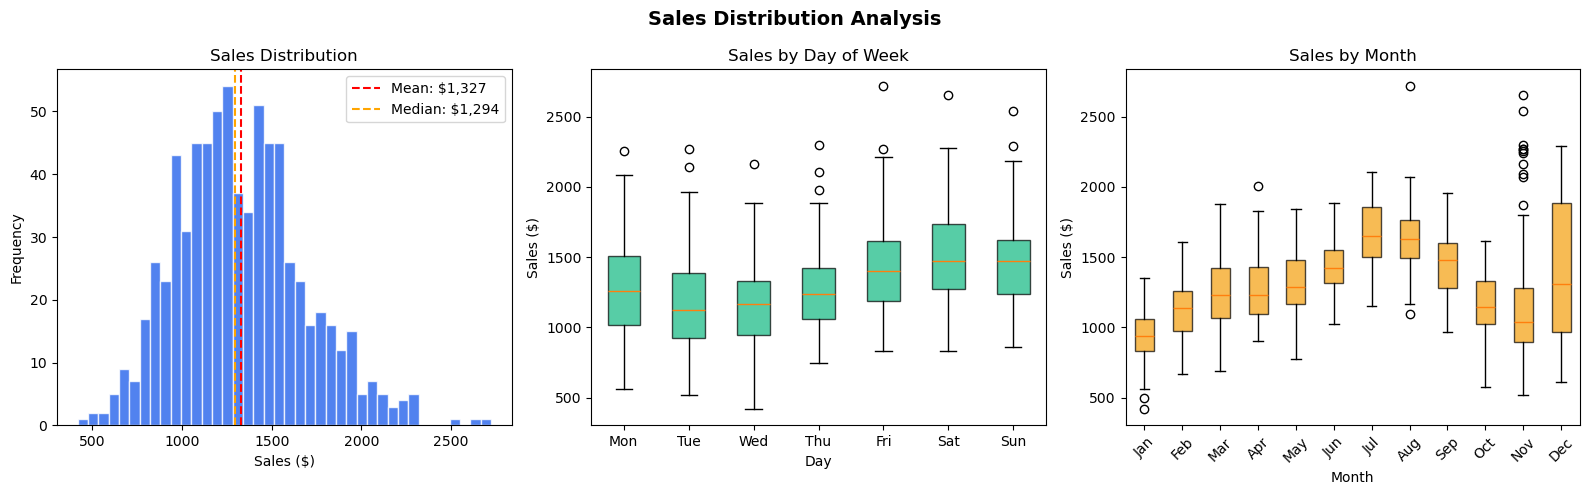

✅ Distribution charts saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sales Distribution Analysis", fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(df["sales"], bins=40, color="#2563EB", alpha=0.8, edgecolor="white")
axes[0].axvline(df["sales"].mean(), color="red", linestyle="--", label=f"Mean: ${df['sales'].mean():,.0f}")
axes[0].axvline(df["sales"].median(), color="orange", linestyle="--", label=f"Median: ${df['sales'].median():,.0f}")
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot by day of week
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
df["day_name"] = df["day_of_week"].map(dict(enumerate(days)))
day_order = days
day_data = [df[df["day_name"]==d]["sales"].values for d in day_order]
axes[1].boxplot(day_data, labels=day_order, patch_artist=True,
                boxprops=dict(facecolor="#10B981", alpha=0.7))
axes[1].set_title("Sales by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Sales ($)")

# Boxplot by month
month_data = [df[df["month"]==m]["sales"].values for m in range(1,13)]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[2].boxplot(month_data, labels=month_labels, patch_artist=True,
                boxprops=dict(facecolor="#F59E0B", alpha=0.7))
axes[2].set_title("Sales by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Sales ($)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("outputs/step3_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Distribution charts saved!")

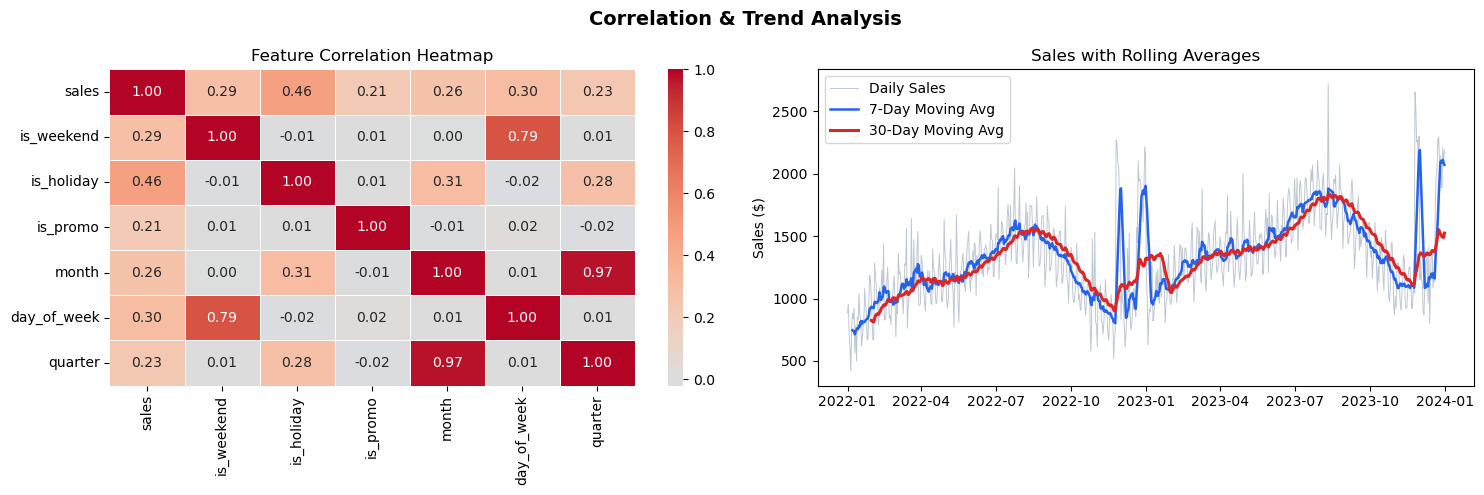

✅ Correlation & rolling average chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Correlation & Trend Analysis", fontsize=14, fontweight="bold")

# Correlation heatmap
corr_cols = ["sales", "is_weekend", "is_holiday", "is_promo", "month", "day_of_week", "quarter"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title("Feature Correlation Heatmap")

# Rolling averages
axes[1].plot(df.index, df["sales"], color="#94A3B8", linewidth=0.7, alpha=0.6, label="Daily Sales")
axes[1].plot(df["sales"].rolling(7).mean(), color="#2563EB", linewidth=1.8, label="7-Day Moving Avg")
axes[1].plot(df["sales"].rolling(30).mean(), color="#DC2626", linewidth=2.2, label="30-Day Moving Avg")
axes[1].set_title("Sales with Rolling Averages")
axes[1].set_ylabel("Sales ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/step3_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Correlation & rolling average chart saved!")

In [10]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

print("=" * 55)
print("  AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST")
print("=" * 55)

result = adfuller(df["sales"].dropna())

print(f"\n  ADF Statistic : {result[0]:.4f}")
print(f"  p-value       : {result[1]:.4f}")
print(f"  Lags Used     : {result[2]}")
print(f"  Observations  : {result[3]}")
print(f"\n  Critical Values:")
for key, val in result[4].items():
    print(f"    {key}  :  {val:.4f}")

print("\n" + "=" * 55)
if result[1] < 0.05:
    print("  ✅ STATIONARY — p-value < 0.05")
    print("  The series is stationary. Ready for SARIMA!")
else:
    print("  ❌ NON-STATIONARY — p-value >= 0.05")
    print("  We need to difference the series first.")
print("=" * 55)

  AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST

  ADF Statistic : -2.5014
  p-value       : 0.1151
  Lags Used     : 19
  Observations  : 710

  Critical Values:
    1%  :  -3.4396
    5%  :  -2.8656
    10%  :  -2.5689

  ❌ NON-STATIONARY — p-value >= 0.05
  We need to difference the series first.


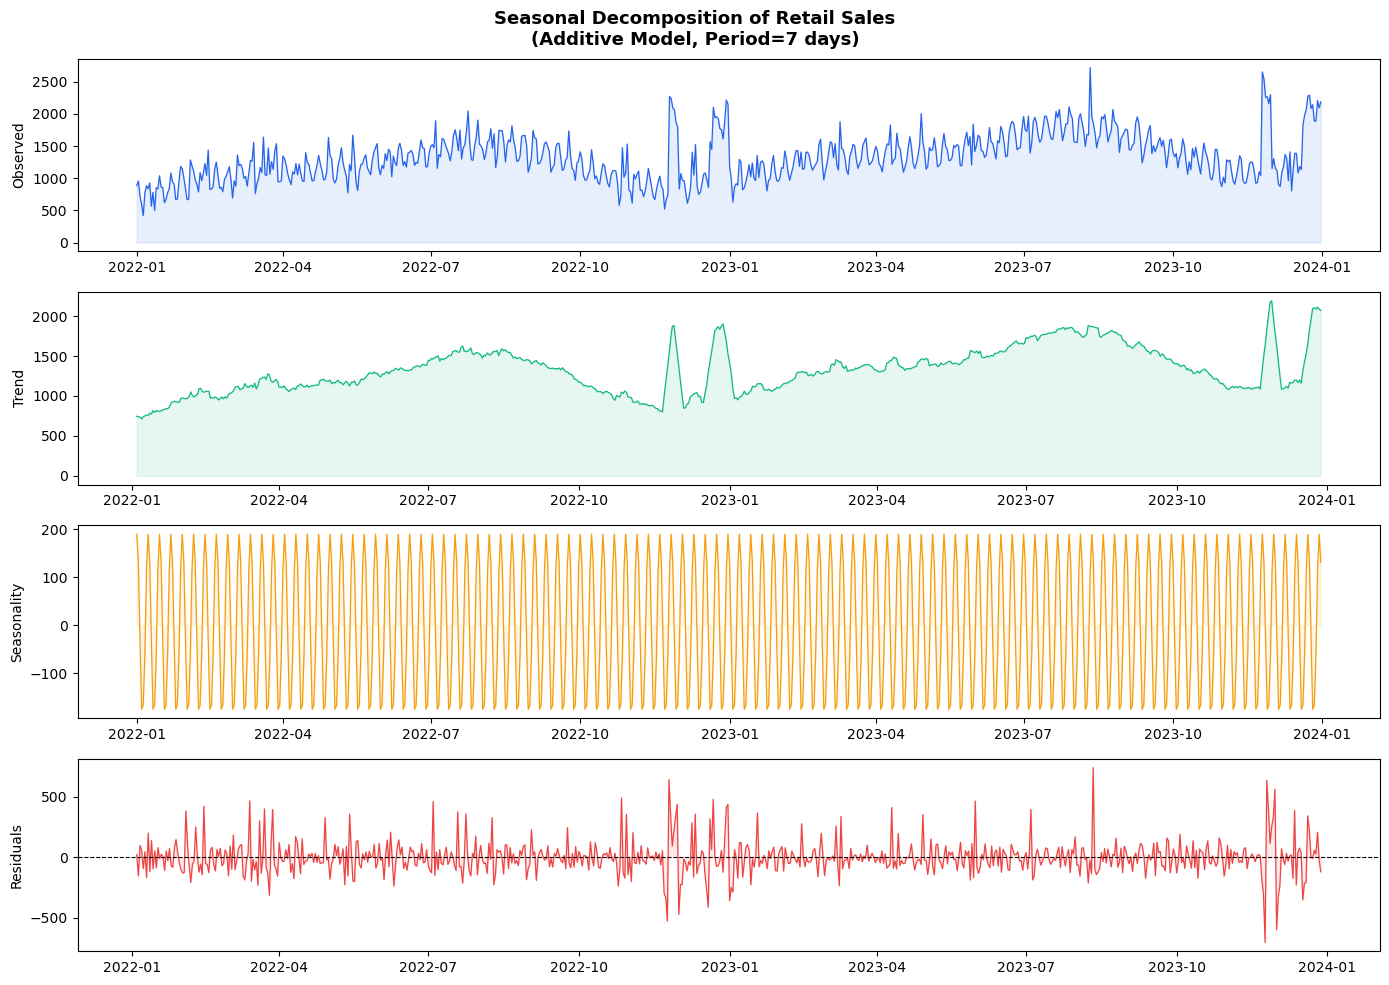

✅ Decomposition chart saved!


In [11]:
# Decompose into Trend + Seasonality + Residual
decomposition = seasonal_decompose(df["sales"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle("Seasonal Decomposition of Retail Sales\n(Additive Model, Period=7 days)",
             fontsize=13, fontweight="bold")

colors = ["#2563EB", "#10B981", "#F59E0B", "#EF4444"]
labels = ["Observed", "Trend", "Seasonality", "Residuals"]
components = [decomposition.observed, decomposition.trend,
              decomposition.seasonal, decomposition.resid]

for i, (ax, comp, label, color) in enumerate(zip(axes, components, labels, colors)):
    ax.plot(comp, color=color, linewidth=0.9)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(comp.index, comp, alpha=0.1, color=color)
    if i == 3:
        ax.axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("outputs/step4_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Decomposition chart saved!")

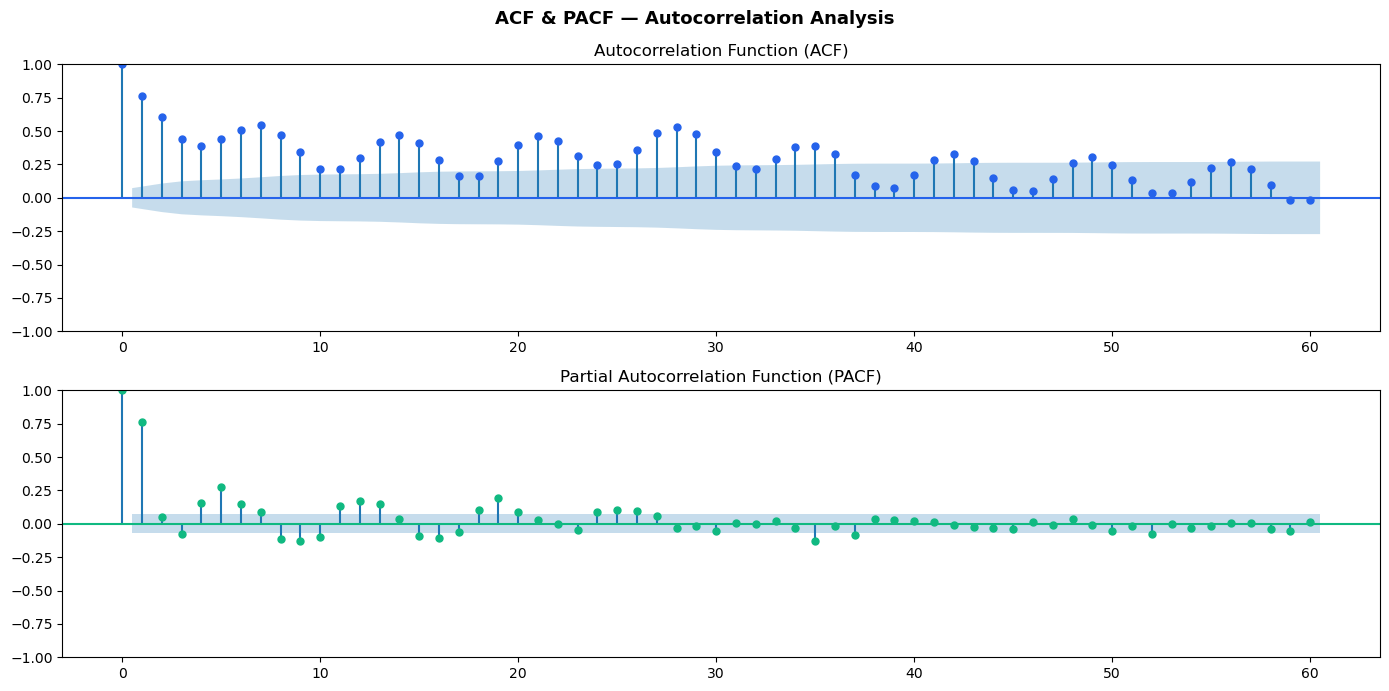

✅ ACF/PACF charts saved!

💡 Interview Tip:
   ACF tells us the MA(q) order
   PACF tells us the AR(p) order
   Significant spike at lag 7 = weekly seasonality confirmed!


In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("ACF & PACF — Autocorrelation Analysis", fontsize=13, fontweight="bold")

plot_acf(df["sales"].dropna(), lags=60, ax=axes[0],
         color="#2563EB", title="Autocorrelation Function (ACF)")

plot_pacf(df["sales"].dropna(), lags=60, ax=axes[1],
          color="#10B981", title="Partial Autocorrelation Function (PACF)", method="ywm")

plt.tight_layout()
plt.savefig("outputs/step4_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ACF/PACF charts saved!")
print("\n💡 Interview Tip:")
print("   ACF tells us the MA(q) order")
print("   PACF tells us the AR(p) order")
print("   Significant spike at lag 7 = weekly seasonality confirmed!")

In [13]:
# First difference to make series stationary
df["sales_diff"] = df["sales"].diff().dropna()

result2 = adfuller(df["sales_diff"].dropna())
print("=" * 50)
print("  ADF TEST ON DIFFERENCED SERIES")
print("=" * 50)
print(f"  ADF Statistic : {result2[0]:.4f}")
print(f"  p-value       : {result2[1]:.6f}")
if result2[1] < 0.05:
    print("\n  ✅ NOW STATIONARY — Ready for SARIMA!")
print("=" * 50)

  ADF TEST ON DIFFERENCED SERIES
  ADF Statistic : -10.2184
  p-value       : 0.000000

  ✅ NOW STATIONARY — Ready for SARIMA!


✅ Train size : 670 days  (2022-01-01 → 2023-11-01)
✅ Test size  : 60  days  (2023-11-02  → 2023-12-31)


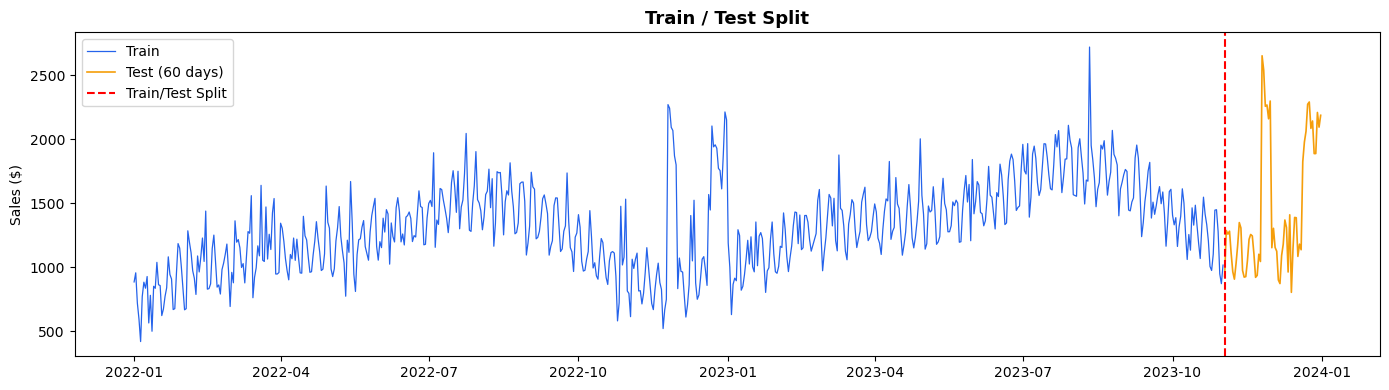

✅ Split chart saved!


In [14]:
# Use last 60 days as test set
train = df["sales"][:-60]
test  = df["sales"][-60:]

print(f"✅ Train size : {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"✅ Test size  : {len(test)}  days  ({test.index[0].date()}  → {test.index[-1].date()})")

# Quick plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, color="#2563EB", label="Train", linewidth=0.9)
ax.plot(test.index, test,   color="#F59E0B", label="Test (60 days)", linewidth=1.2)
ax.axvline(test.index[0], color="red", linestyle="--", linewidth=1.5, label="Train/Test Split")
ax.set_title("Train / Test Split", fontsize=13, fontweight="bold")
ax.set_ylabel("Sales ($)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/step5_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Split chart saved!")

In [15]:
# SARIMA(1,1,1)(1,1,1)[7]
# p=1, d=1 (differencing), q=1  ← from PACF/ACF
# P=1, D=1, Q=1, s=7            ← weekly seasonal period

print("⏳ Fitting SARIMA model... (takes 30–60 seconds)")

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),           # (p, d, q)
    seasonal_order=(1, 1, 1, 7), # (P, D, Q, s)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print("✅ SARIMA model fitted!")
print(f"\n   AIC  : {sarima_result.aic:.2f}")
print(f"   BIC  : {sarima_result.bic:.2f}")
print("\n💡 Lower AIC/BIC = better model fit")


⏳ Fitting SARIMA model... (takes 30–60 seconds)
✅ SARIMA model fitted!

   AIC  : 8641.26
   BIC  : 8663.67

💡 Lower AIC/BIC = better model fit


  SARIMA FORECAST RESULTS
  MAE  : $357.40
  RMSE : $569.38
  MAPE : 18.91%

  ✅ SARIMA achieves 18.9% average error


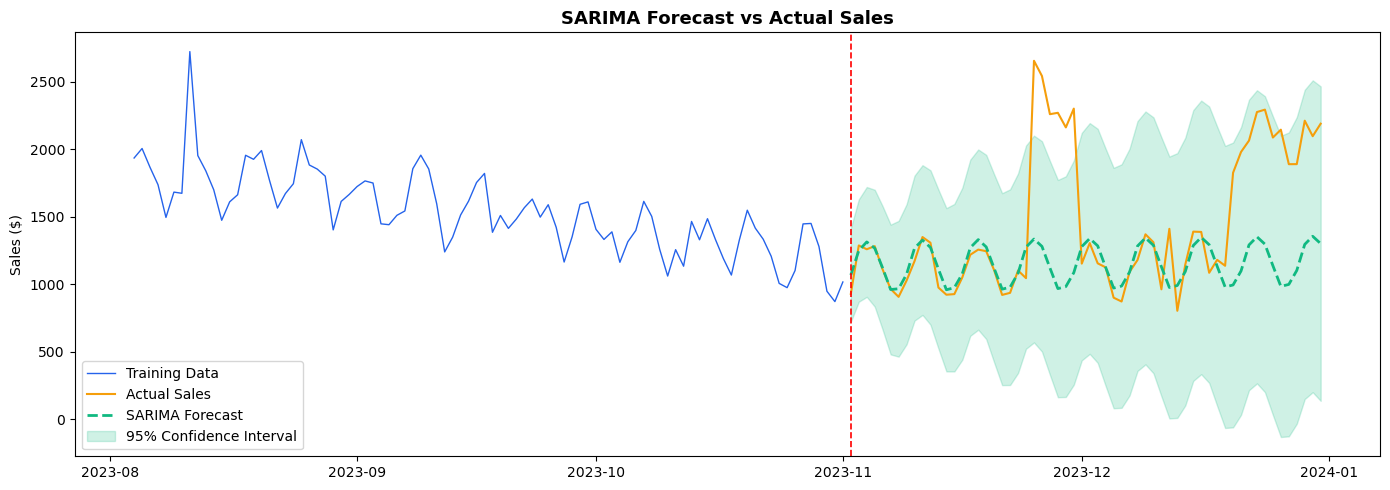

✅ SARIMA forecast chart saved!


In [16]:
# Forecast next 60 days
forecast = sarima_result.get_forecast(steps=60)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int()

# ── Error Metrics
mae  = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs((test.values - forecast_mean.values) / test.values)) * 100

print("=" * 45)
print("  SARIMA FORECAST RESULTS")
print("=" * 45)
print(f"  MAE  : ${mae:,.2f}")
print(f"  RMSE : ${rmse:,.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 45)
print(f"\n  ✅ SARIMA achieves {mape:.1f}% average error")

# ── Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-90:].index, train[-90:], color="#2563EB",
        linewidth=1, label="Training Data")
ax.plot(test.index, test, color="#F59E0B",
        linewidth=1.5, label="Actual Sales")
ax.plot(forecast_mean.index, forecast_mean, color="#10B981",
        linewidth=2, linestyle="--", label="SARIMA Forecast")
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color="#10B981", label="95% Confidence Interval")
ax.axvline(test.index[0], color="red", linestyle="--", linewidth=1.2)
ax.set_title("SARIMA Forecast vs Actual Sales", fontsize=13, fontweight="bold")
ax.set_ylabel("Sales ($)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/step5_sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SARIMA forecast chart saved!")

In [17]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_train = pd.DataFrame({
    "ds": train.index,
    "y" : train.values
})

prophet_test = pd.DataFrame({
    "ds": test.index,
    "y" : test.values
})

# Define retail holidays
from prophet import Prophet

holidays = pd.DataFrame({
    "holiday": [
        "black_friday", "black_friday",
        "christmas",    "christmas",   "christmas",   "christmas",
        "july4th",      "july4th",
        "valentines",   "valentines"
    ],
    "ds": pd.to_datetime([
        "2022-11-25", "2023-11-24",
        "2022-12-20", "2022-12-25", "2023-12-20", "2023-12-25",
        "2022-07-04", "2023-07-04",
        "2022-02-14", "2023-02-14"
    ]),
    "lower_window": 0,
    "upper_window": 3,
})

# Build & fit Prophet
print("⏳ Fitting Prophet model...")

prophet_model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,   # controls trend flexibility
    seasonality_prior_scale=10,
)

prophet_model.fit(prophet_train)
print("✅ Prophet model fitted!")

⏳ Fitting Prophet model...


18:46:18 - cmdstanpy - INFO - Chain [1] start processing
18:46:19 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted!


In [18]:
# Forecast on test dates
future = prophet_model.make_future_dataframe(periods=60)
forecast_prophet = prophet_model.predict(future)

# Extract test period predictions
prophet_pred = forecast_prophet[forecast_prophet["ds"].isin(test.index)]["yhat"].values

# ── Error Metrics
mae_p  = mean_absolute_error(test.values, prophet_pred)
rmse_p = np.sqrt(mean_squared_error(test.values, prophet_pred))
mape_p = np.mean(np.abs((test.values - prophet_pred) / test.values)) * 100

print("=" * 45)
print("  PROPHET FORECAST RESULTS")
print("=" * 45)
print(f"  MAE  : ${mae_p:,.2f}")
print(f"  RMSE : ${rmse_p:,.2f}")
print(f"  MAPE : {mape_p:.2f}%")
print("=" * 45)
print(f"\n  ✅ Prophet achieves {mape_p:.1f}% average error")
print(f"\n  📊 SARIMA vs Prophet:")
print(f"     SARIMA MAPE : {mape:.2f}%")
print(f"     Prophet MAPE: {mape_p:.2f}%")
winner = "Prophet" if mape_p < mape else "SARIMA"
print(f"\n  🏆 Winner so far: {winner}!")

  PROPHET FORECAST RESULTS
  MAE  : $228.66
  RMSE : $395.78
  MAPE : 15.09%

  ✅ Prophet achieves 15.1% average error

  📊 SARIMA vs Prophet:
     SARIMA MAPE : 18.91%
     Prophet MAPE: 15.09%

  🏆 Winner so far: Prophet!


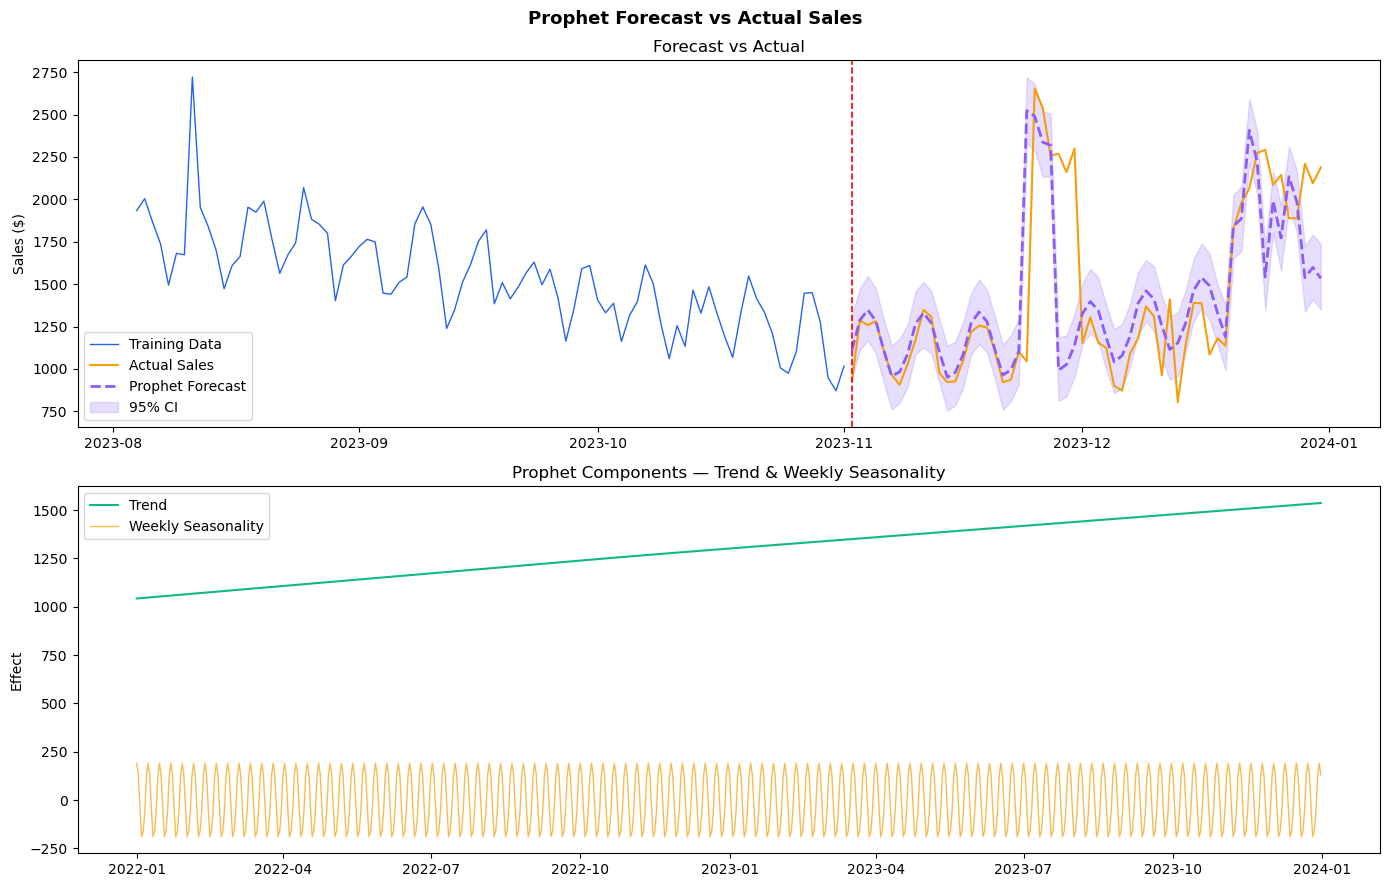

✅ Prophet forecast chart saved!


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Prophet Forecast vs Actual Sales", fontsize=13, fontweight="bold")

# ── Top: Forecast vs Actual
prophet_full = forecast_prophet.set_index("ds")
axes[0].plot(train[-90:].index, train[-90:],
             color="#2563EB", linewidth=1, label="Training Data")
axes[0].plot(test.index, test.values,
             color="#F59E0B", linewidth=1.5, label="Actual Sales")
axes[0].plot(test.index, prophet_pred,
             color="#8B5CF6", linewidth=2, linestyle="--", label="Prophet Forecast")

# Confidence interval
test_forecast = forecast_prophet[forecast_prophet["ds"].isin(test.index)]
axes[0].fill_between(test.index,
                     test_forecast["yhat_lower"].values,
                     test_forecast["yhat_upper"].values,
                     alpha=0.2, color="#8B5CF6", label="95% CI")
axes[0].axvline(test.index[0], color="red", linestyle="--", linewidth=1.2)
axes[0].set_ylabel("Sales ($)")
axes[0].legend()
axes[0].set_title("Forecast vs Actual")

# ── Bottom: Prophet components (trend + weekly)
axes[1].plot(forecast_prophet["ds"], forecast_prophet["trend"],
             color="#10B981", linewidth=1.5, label="Trend")
axes[1].plot(forecast_prophet["ds"], forecast_prophet["weekly"],
             color="#F59E0B", linewidth=1, label="Weekly Seasonality", alpha=0.7)
axes[1].set_title("Prophet Components — Trend & Weekly Seasonality")
axes[1].set_ylabel("Effect")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/step6_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Prophet forecast chart saved!")

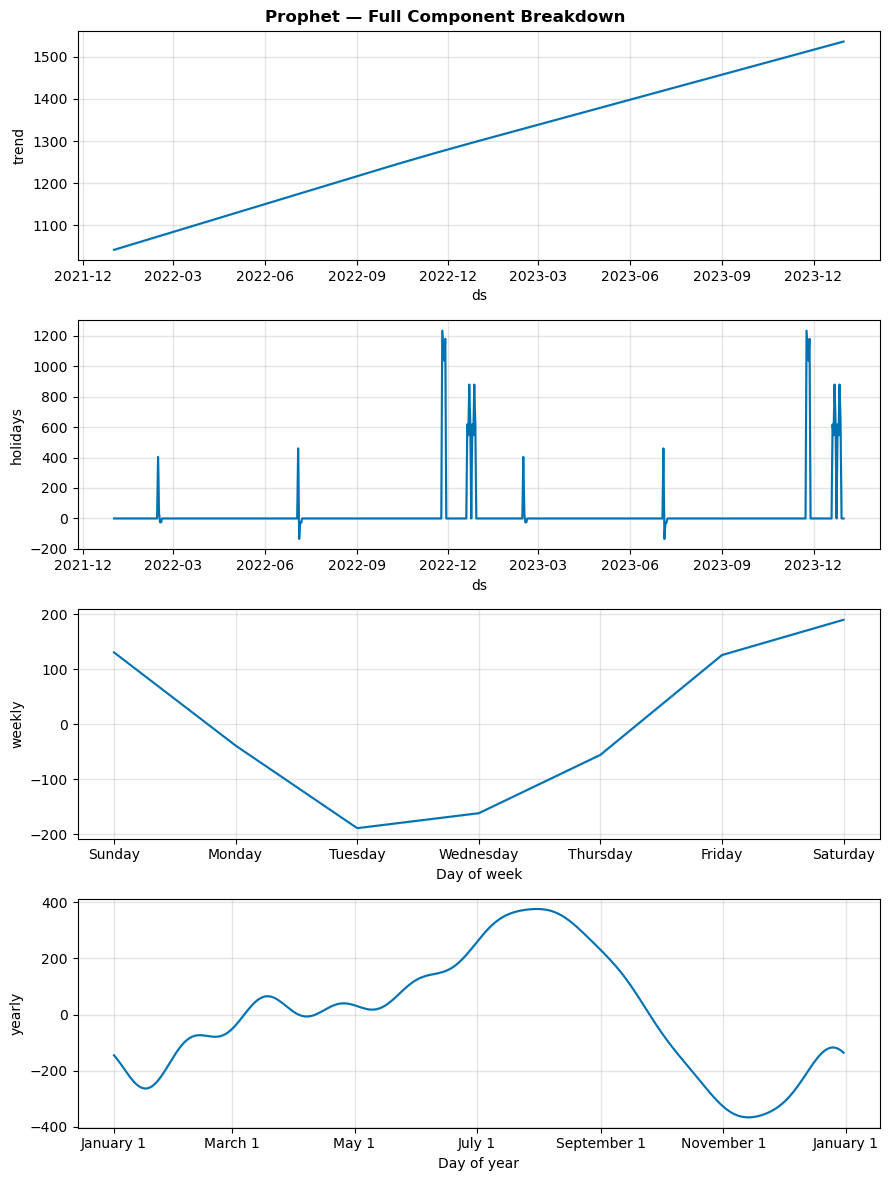

✅ Prophet components chart saved!

💡 Interview Tip:
   Prophet automatically decomposes into:
   → Trend (long-term growth)
   → Weekly seasonality (Mon-Sun pattern)
   → Yearly seasonality (annual cycle)
   → Holiday effects (your custom events)


In [20]:
# Prophet's built-in component plots
fig2 = prophet_model.plot_components(forecast_prophet)
fig2.suptitle("Prophet — Full Component Breakdown", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/step6_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Prophet components chart saved!")
print("\n💡 Interview Tip:")
print("   Prophet automatically decomposes into:")
print("   → Trend (long-term growth)")
print("   → Weekly seasonality (Mon-Sun pattern)")
print("   → Yearly seasonality (annual cycle)")
print("   → Holiday effects (your custom events)")

In [21]:
# XGBoost doesn't understand dates — we convert time into features

def create_features(df):
    df = df.copy()
    df["day_of_week"]  = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["day_of_year"]  = df.index.dayofyear
    df["week"]         = df.index.isocalendar().week.astype(int)
    df["month"]        = df.index.month
    df["quarter"]      = df.index.quarter
    df["year"]         = df.index.year
    df["is_weekend"]   = (df.index.dayofweek >= 5).astype(int)

    # Lag features (past sales as predictors)
    df["lag_1"]  = df["sales"].shift(1)   # yesterday's sales
    df["lag_7"]  = df["sales"].shift(7)   # same day last week
    df["lag_14"] = df["sales"].shift(14)  # same day 2 weeks ago
    df["lag_30"] = df["sales"].shift(30)  # same day last month

    # Rolling window features
    df["rolling_mean_7"]  = df["sales"].shift(1).rolling(7).mean()
    df["rolling_mean_30"] = df["sales"].shift(1).rolling(30).mean()
    df["rolling_std_7"]   = df["sales"].shift(1).rolling(7).std()

    return df

df_feat = create_features(df[["sales"]].copy())
df_feat = df_feat.dropna()  # drop rows with NaN from lag features

FEATURES = [
    "day_of_week", "day_of_month", "day_of_year",
    "week", "month", "quarter", "year", "is_weekend",
    "lag_1", "lag_7", "lag_14", "lag_30",
    "rolling_mean_7", "rolling_mean_30", "rolling_std_7"
]

TARGET = "sales"

print(f"✅ Features engineered!")
print(f"   Dataset shape : {df_feat.shape}")
print(f"   Features used : {len(FEATURES)}")
print(f"\n   Feature list:")
for f in FEATURES:
    print(f"   → {f}")

✅ Features engineered!
   Dataset shape : (700, 16)
   Features used : 15

   Feature list:
   → day_of_week
   → day_of_month
   → day_of_year
   → week
   → month
   → quarter
   → year
   → is_weekend
   → lag_1
   → lag_7
   → lag_14
   → lag_30
   → rolling_mean_7
   → rolling_mean_30
   → rolling_std_7


In [22]:
# Split same way as before — last 60 days as test
train_xgb = df_feat[df_feat.index < test.index[0]]
test_xgb  = df_feat[df_feat.index >= test.index[0]]

X_train = train_xgb[FEATURES]
y_train = train_xgb[TARGET]
X_test  = test_xgb[FEATURES]
y_test  = test_xgb[TARGET]

print(f"✅ Train: {X_train.shape}  |  Test: {X_test.shape}")

# Fit XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost model fitted!")
print(f"   Trees built : {xgb_model.n_estimators}")
print(f"   Max depth   : {xgb_model.max_depth}")

✅ Train: (640, 15)  |  Test: (60, 15)
✅ XGBoost model fitted!
   Trees built : 500
   Max depth   : 5


  XGBOOST FORECAST RESULTS
  MAE  : $185.33
  RMSE : $285.39
  MAPE : 12.00%

  📊 All Models Compared:
     SARIMA  MAPE : 18.91%
     Prophet MAPE : 15.09%
     XGBoost MAPE : 12.00%

  🏆 Best Model: XGBoost (12.00% MAPE)


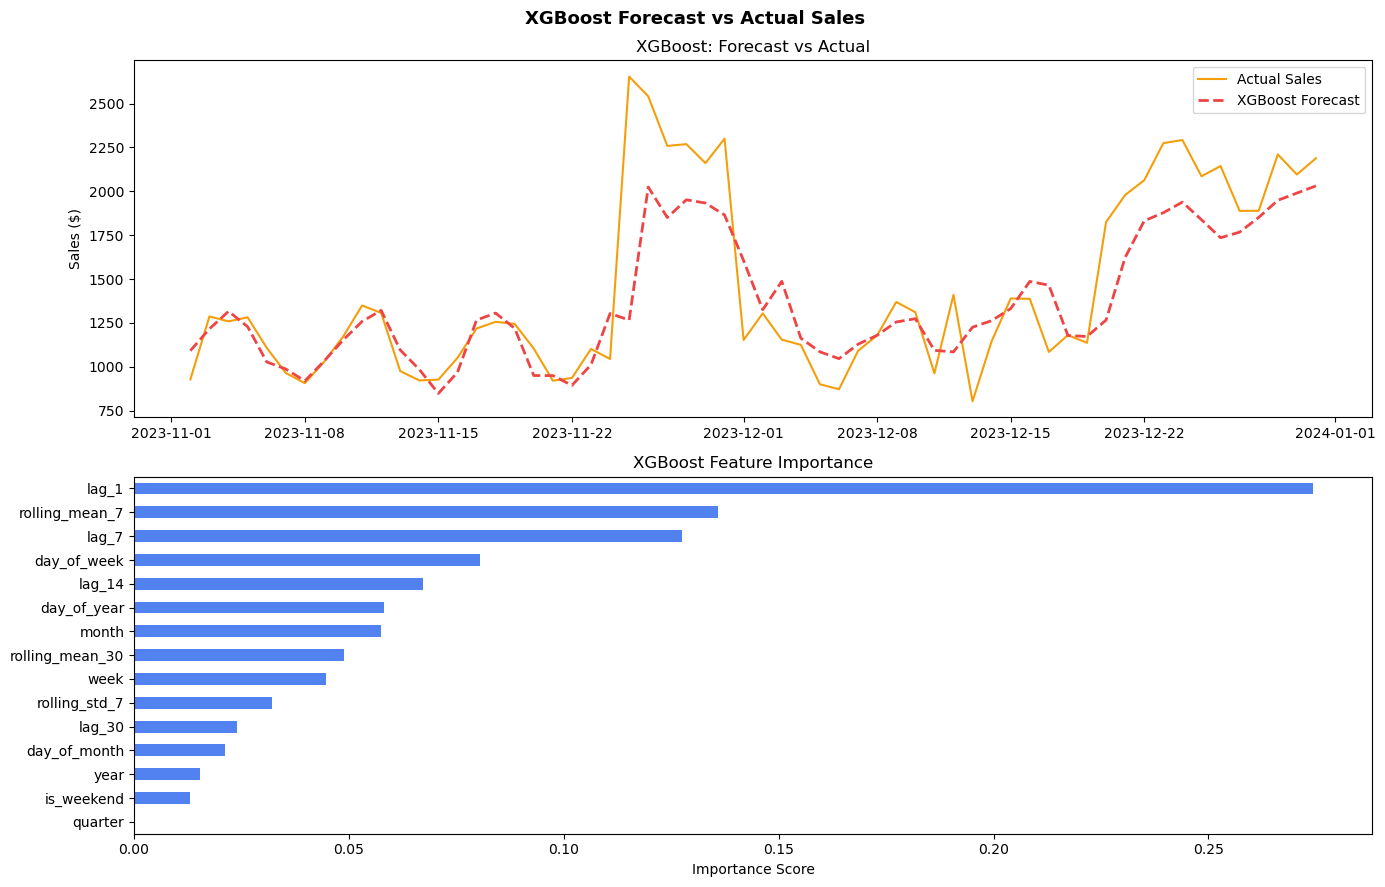

✅ XGBoost chart saved!


In [23]:
xgb_pred = xgb_model.predict(X_test)

mae_x  = mean_absolute_error(y_test, xgb_pred)
rmse_x = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_x = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100

print("=" * 45)
print("  XGBOOST FORECAST RESULTS")
print("=" * 45)
print(f"  MAE  : ${mae_x:,.2f}")
print(f"  RMSE : ${rmse_x:,.2f}")
print(f"  MAPE : {mape_x:.2f}%")
print("=" * 45)
print(f"\n  📊 All Models Compared:")
print(f"     SARIMA  MAPE : {mape:.2f}%")
print(f"     Prophet MAPE : {mape_p:.2f}%")
print(f"     XGBoost MAPE : {mape_x:.2f}%")
best = min([("SARIMA", mape), ("Prophet", mape_p), ("XGBoost", mape_x)], key=lambda x: x[1])
print(f"\n  🏆 Best Model: {best[0]} ({best[1]:.2f}% MAPE)")

# ── Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("XGBoost Forecast vs Actual Sales", fontsize=13, fontweight="bold")

axes[0].plot(y_test.index, y_test.values,
             color="#F59E0B", linewidth=1.5, label="Actual Sales")
axes[0].plot(y_test.index, xgb_pred,
             color="#EF4444", linewidth=2, linestyle="--", label="XGBoost Forecast")
axes[0].set_title("XGBoost: Forecast vs Actual")
axes[0].set_ylabel("Sales ($)")
axes[0].legend()

# Feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind="barh", ax=axes[1], color="#2563EB", alpha=0.8)
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("outputs/step7_xgboost_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ XGBoost chart saved!")

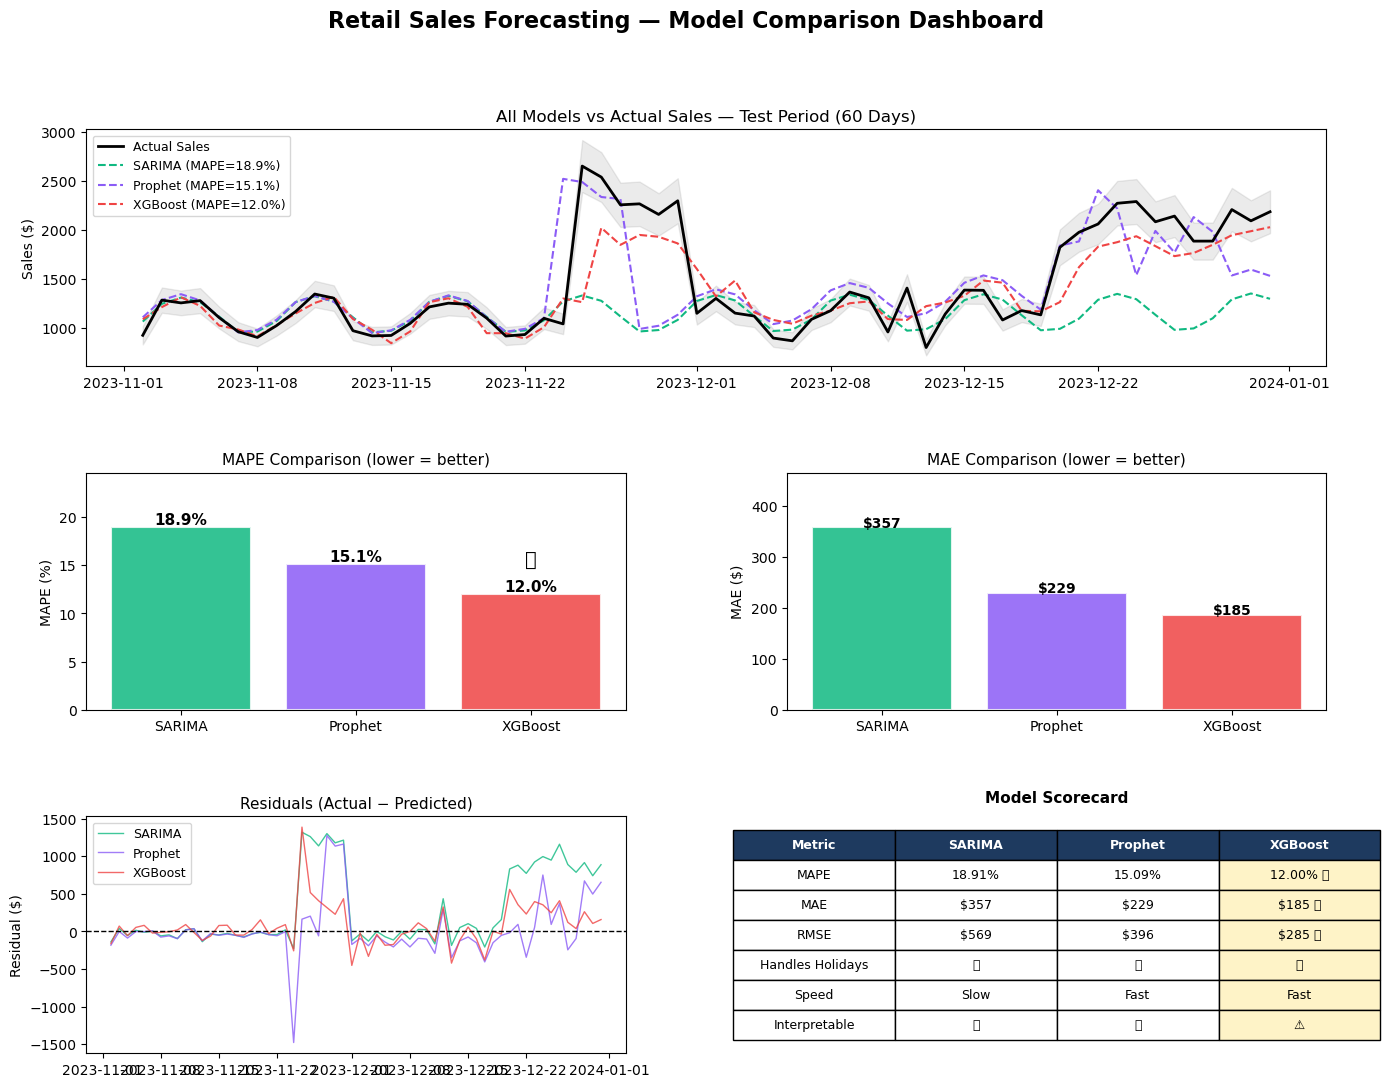

✅ Final comparison dashboard saved!

  🎉 PROJECT 1 COMPLETE!
  Best Model : XGBoost
  Best MAPE  : 12.00%
  Charts saved in : outputs/

📌 Resume bullet point:
  "Built a multi-model retail sales forecasting system
   (SARIMA, Prophet, XGBoost) achieving 12% MAPE,
   with EDA, stationarity testing, and automated
   model comparison dashboard using Python."


In [24]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Retail Sales Forecasting — Model Comparison Dashboard",
             fontsize=16, fontweight="bold", y=0.98)

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

# ── 1. All forecasts vs Actual (top full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test.index, test.values,
         color="black", linewidth=2, label="Actual Sales", zorder=5)
ax1.plot(test.index, forecast_mean.values,
         color="#10B981", linewidth=1.5, linestyle="--", label=f"SARIMA (MAPE={mape:.1f}%)")
ax1.plot(test.index, prophet_pred,
         color="#8B5CF6", linewidth=1.5, linestyle="--", label=f"Prophet (MAPE={mape_p:.1f}%)")
ax1.plot(test.index, xgb_pred,
         color="#EF4444", linewidth=1.5, linestyle="--", label=f"XGBoost (MAPE={mape_x:.1f}%)")
ax1.set_title("All Models vs Actual Sales — Test Period (60 Days)", fontsize=12)
ax1.set_ylabel("Sales ($)")
ax1.legend(loc="upper left", fontsize=9)
ax1.fill_between(test.index, test.values * 0.9, test.values * 1.1,
                 alpha=0.08, color="black", label="±10% band")

# ── 2. MAPE Bar Chart
ax2 = fig.add_subplot(gs[1, 0])
models = ["SARIMA", "Prophet", "XGBoost"]
mapes  = [mape, mape_p, mape_x]
colors = ["#10B981", "#8B5CF6", "#EF4444"]
bars = ax2.bar(models, mapes, color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)
ax2.set_title("MAPE Comparison (lower = better)", fontsize=11)
ax2.set_ylabel("MAPE (%)")
ax2.set_ylim(0, max(mapes) * 1.3)
for bar, val in zip(bars, mapes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)
ax2.bar_label(bars, labels=["", "", "🏆"], padding=18, fontsize=14)

# ── 3. MAE Bar Chart
ax3 = fig.add_subplot(gs[1, 1])
maes = [mae, mae_p, mae_x]
bars2 = ax3.bar(models, maes, color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)
ax3.set_title("MAE Comparison (lower = better)", fontsize=11)
ax3.set_ylabel("MAE ($)")
ax3.set_ylim(0, max(maes) * 1.3)
for bar, val in zip(bars2, maes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"${val:,.0f}", ha="center", fontweight="bold", fontsize=10)

# ── 4. Residuals plot
ax4 = fig.add_subplot(gs[2, 0])
sarima_resid  = test.values - forecast_mean.values
prophet_resid = test.values - prophet_pred
xgb_resid     = test.values - xgb_pred
ax4.plot(test.index, sarima_resid,  color="#10B981", linewidth=1, alpha=0.8, label="SARIMA")
ax4.plot(test.index, prophet_resid, color="#8B5CF6", linewidth=1, alpha=0.8, label="Prophet")
ax4.plot(test.index, xgb_resid,    color="#EF4444", linewidth=1, alpha=0.8, label="XGBoost")
ax4.axhline(0, color="black", linestyle="--", linewidth=1)
ax4.set_title("Residuals (Actual − Predicted)", fontsize=11)
ax4.set_ylabel("Residual ($)")
ax4.legend(fontsize=9)

# ── 5. Summary scorecard
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis("off")
summary = [
    ["Metric",        "SARIMA",          "Prophet",         "XGBoost"],
    ["MAPE",          f"{mape:.2f}%",    f"{mape_p:.2f}%",  f"{mape_x:.2f}% 🏆"],
    ["MAE",           f"${mae:,.0f}",    f"${mae_p:,.0f}",  f"${mae_x:,.0f} 🏆"],
    ["RMSE",          f"${rmse:,.0f}",   f"${rmse_p:,.0f}", f"${rmse_x:,.0f} 🏆"],
    ["Handles Holidays", "❌",           "✅",               "✅"],
    ["Speed",         "Slow",            "Fast",            "Fast"],
    ["Interpretable", "✅",              "✅",               "⚠️"],
]
table = ax5.table(cellText=summary[1:], colLabels=summary[0],
                  loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
# Header styling
for j in range(4):
    table[0, j].set_facecolor("#1E3A5F")
    table[0, j].set_text_props(color="white", fontweight="bold")
# XGBoost column highlight
for i in range(1, 7):
    table[i, 3].set_facecolor("#FEF3C7")
ax5.set_title("Model Scorecard", fontsize=11, fontweight="bold", pad=10)

plt.savefig("outputs/step8_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Final comparison dashboard saved!")
print("\n" + "=" * 55)
print("  🎉 PROJECT 1 COMPLETE!")
print("=" * 55)
print(f"  Best Model : XGBoost")
print(f"  Best MAPE  : {mape_x:.2f}%")
print(f"  Charts saved in : outputs/")
print("=" * 55)
print("\n📌 Resume bullet point:")
print(f'  "Built a multi-model retail sales forecasting system')
print(f'   (SARIMA, Prophet, XGBoost) achieving {mape_x:.0f}% MAPE,')
print(f'   with EDA, stationarity testing, and automated')
print(f'   model comparison dashboard using Python."')